# Finite Element Head Model Creation

The model mesh is created from a T1 image and FreeSurfer segmentation in the following steps:
1. Set up modules and directories
    1. Load fsl and FreeSurfer
    2. Create a temporary directory (tmp) to save images
    3. Create a directory to save FAST segmentation performed by fsl
2. Image preprocessing and rigid registration
    1. Convert FreeSurfer raw files (T1.mgz, brain.mgz and aseg.mgz) to NifTI format
    2. Rigidly register the brain-extracted image to MNI standard space
    3. Apply the rigid registration matrix to T1 and aseg files   
3. Do FAST segmentation
    1. Run FAST on T1 in standard space
    2. Extract Grey Matter, White Matter, and CSF from FAST output
4. Find differences of FAST and FreeSurfer segmentations
    1. Find voxels present in FAST gm and wm mask but not in FreeSurfer mask (this is to ensure there are no missing voxels)
    2. Add voxels to FreeSurfer segmentation under intensity no. 300
5. Add CSF to FreeSurfer segmentation
    1. Remove ventricles from FAST segmentation
    2. Remove overlap of brain matter to CSF from FAST segmentation
    3. Add CSF from FAST segmentation to FreeSurfer segmentation
    4. Fill small holes of CSF
6. Add skull to FreeSurfer segmentation
    1. Apply noise reduction filter to T1 (susan)
    2. Remove lower face (to make model anonymous) 
    3. Create mask of voxels immediately surrounding CSF
    4. Remove voxels of FreeSurfer segmentation from T1
    5. Create complete skull mask from previous two steps
    6. Add to FreeSurfer segmentation
7. Mesh generation
    1. Direct voxel-to-element conversion
    2. Smoothing the mesh to remove stair-step artifacts 
    3. Removing any potential contacts between brain and skull/skin elements

# Model creation, verification, and testing

This notebook will create a model from a T1 image and a FreeSurfer segmented head and will verify the smoothed mesh against various selected curves. 

## Dependencies

### Packages
There are a number of python modules required for this noteebook to work. They are already prepared for import in the cell below. You will need to make sure FSL is available (this is already on the HPC, as well as the python neuroscience package Nibabel. You can install the latter by following the instructions

A dirty way of installing nibabel to your current kernel is using the code: 

    {sys.executable} -m pip install nibabel

Run the code cell beneath to install the module onto the current kernal (top right corner). **If already installed skip to import standard modules**

Code to install additional modules not avalible on the current kernal. Only run if necessary

In [ ]:
#!{sys.executable} -m pip install --upgrade matplotlib
!{sys.executable} -m pip install --user ipython-autotime

time: 1.06 s (started: 2026-01-03 03:55:31 +00:00)


In [ ]:
# Standard modules
import os
import sys
import csv
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.signal 
import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

# you can disable timing of cells by commenting out the following line
%load_ext autotime
%matplotlib inline

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 2.34 ms (started: 2026-01-03 03:55:32 +00:00)


##### Directories

The following folders and files should exist in the subjects folder:

- img/fs_seg/mri/aseg.mgz
- img/fs_seg/mri/brain.mgz
- img/T1.mgz 

In [ ]:
# Location of directory containing resources and dependencies (rs)
wrk_dir = "/rds/general/user/vd23/home/pipeline/dependencies"

# Location of folder containing folders for the subject, and will need a T1 and a FreeSurfer (subjects/subject)
sub_dir = "/rds/general/user/vd23/home/pipeline/subjects/"

# We point to the specific folder where mesh_utils.py lives ('rs' subfolder) by Vahid
scripts_dir = os.path.join(wrk_dir, "rs")

time: 529 µs (started: 2026-01-03 04:13:58 +00:00)


##### Custom module

In [ ]:
import os
os.chdir(wrk_dir)
scripts_path = os.path.join(wrk_dir, "rs")

if scripts_path not in sys.path:
    sys.path.append(scripts_path)
import bmctk

time: 224 µs (started: 2026-01-03 03:55:32 +00:00)


##### Subject details

In [ ]:
# Define folder name and mesh size of subjects
#     This folder must be present in sub_dir
subject_folder = 'TBI-generic-after-rigid-registration-sub0196' 

# Define output folder name
output_name = "output"

# T1/T2 image names
T1 = 'T1.nii.gz'
T2 = ''

time: 371 µs (started: 2026-01-03 03:55:32 +00:00)


##### Imaging customisation

In [42]:
# Minimum intensity value in T1 of image values where noise is lower
# For more details see: https://fsl.fmrib.ox.ac.uk/fsl/fslwiki/SUSAN
threshold_filter = 10

# Percent of skull from bottom to exclude to keep pricavy of individual, from 
# inferior to superior. 30% is normally adequate to remove most
# of the facial features but leave behind enough for good visuals
skull_privacy_percentage = 0

time: 306 µs (started: 2026-01-03 03:55:33 +00:00)


##### Mesh creation variables

In [ ]:
# Set mesh size (this is in mm)
mesh_size = 1.5

# Voxel correction variables
# (it is recomended not to change these settings unless you have
# issues with parts having elements present in other parts which 
# increases timestep)
iterations = 3
blocks = 1
threshold = 0.9 # the threshold of the amount of neighbours not 
                # the same for a voxel to be changed between 0 and 1


# Apply manual cog edits (This is for generating the center of gravity to apply the acceleration needed for TBI simulations)
cog_id = 80000000
change_ap = 0
change_lr = 0 
change_is = 0
change_cog = [change_ap, change_lr, change_is]

time: 575 µs (started: 2026-01-03 03:55:34 +00:00)


##### Verification Curve Variables

In [44]:
colour_palette = 'CMRmap_r'

time: 237 µs (started: 2026-01-03 03:55:35 +00:00)


##### Verification Variables

In [45]:
import os 
os.chdir(sub_dir)

# Set nodeout interval time
dt = 0.5
d3plot_dt = 1

# Submission files
private_queue = True
queue = 'pqaeromg'
walltime = '168:00:00'
ncpus = 20
memory = "24gb"

time: 646 µs (started: 2026-01-03 03:55:36 +00:00)


### Checking folders

In [ ]:
%%bash -s "$sub_dir" "$subject_folder"

echo "$1"

# load modules fsl and FreeSurfer
module load fsl/6.0.1;

# Move bash cwd to subject folder
cd $1/
echo "Moved to: "$1"";

# Check if subject in question is present
if [ ! -d "$2" ]; then
        # Will not run if cannot find subject folder
        echo "Subject "$2" not found in "$1""
else
    echo "Setting up folders in $2"
    cd "$2"
    
    if [ -d tmp  ] && [ -d img/fast  ] && [ -d img/bet  ]
    then
        echo "Some folders already exist in $2"
        echo "To prevent overwriting back up or save under a different name"
    else 
        mkdir tmp
        mkdir -p img/fast
        mkdir -p img/bet
    fi

fi

/rds/general/user/vd23/home/pipeline/subjects/
Moved to: /rds/general/user/vd23/home/pipeline/subjects/
Setting up folders in TBI-generic-after-rigid-registration-sub0196
Some folders already exist in TBI-generic-after-rigid-registration-sub0196
To prevent overwriting back up or save under a different name


=== THIS MESSAGE IS NOT AN ERROR ===

You are loading fsl/6.0.1
Please consider moving to our newer cluster - CX3 Phase 2
as there will be either the same or a newer version of the software available

More info can be found here:
https://icl-rcs-user-guide.readthedocs.io/en/latest/hpc/pilot/cx3-phase2/
https://icl-rcs-user-guide.readthedocs.io/en/latest/hpc/pilot/cx3-phase2/#python-and-conda-environments



Loading fsl/6.0.1
  Loading requirement: fix_unwritable_tmp


time: 134 ms (started: 2026-01-03 03:55:38 +00:00)


# Rigid registration and Image Alignment

In [ ]:
%%bash -s "$sub_dir" "$subject_folder"

# --- 1. Setup Modules & Paths ---
module load freesurfer/6.0.0
module load fsl/6.0.1
# Ensure FreeSurfer environment is set if needed (standard on most HPCs)
source $FREESURFER_HOME/SetUpFreeSurfer.sh > /dev/null 2>&1

SUB_PATH="$1/$2"
IMG_DIR="${SUB_PATH}/img"
TMP_DIR="${SUB_PATH}/tmp"
FAST_DIR="${IMG_DIR}/fast"
mkdir -p "$FAST_DIR" "$TMP_DIR"

# Standard MNI Brain Template
MNI_REF="${FSLDIR}/data/standard/MNI152_T1_1mm_brain.nii.gz"

# --- 2. Convert MGZ to NIfTI (Raw) ---
echo "Step 1: Converting FreeSurfer MGZ to NIfTI..."
mri_convert "${IMG_DIR}/fs_seg/mri/brain.mgz" "${TMP_DIR}/brain_raw.nii.gz"
mri_convert "${IMG_DIR}/T1.mgz" "${TMP_DIR}/T1_raw.nii.gz"
mri_convert "${IMG_DIR}/fs_seg/mri/aseg.mgz" "${TMP_DIR}/aseg_raw.nii.gz"

# --- 3. Rigid Registration (Brain -> MNI) ---
# We calculate the transform using the skull-stripped brain for better accuracy
echo "Step 2: Calculating Rigid Registration (Brain -> MNI)..."
flirt -in "${TMP_DIR}/brain_raw.nii.gz" \
      -ref "${MNI_REF}" \
      -out "${FAST_DIR}/brain_std.nii.gz" \
      -omat "${TMP_DIR}/brain_to_mni.mat" \
      -dof 6 \
      -searchrx -90 90 -searchry -90 90 -searchrz -90 90

# --- 4. Apply Transform to T1
echo "Step 3: Applying transform to T1..."
flirt -in "${TMP_DIR}/T1_raw.nii.gz" \
      -ref "${MNI_REF}" \
      -out "${TMP_DIR}/T1_std.nii.gz" \
      -applyxfm -init "${TMP_DIR}/brain_to_mni.mat" \
      -interp trilinear

# --- 5. Apply Transform to Aseg
echo "Step 4: Applying transform to Aseg..."
flirt -in "${TMP_DIR}/aseg_raw.nii.gz" \
      -ref "${MNI_REF}" \
      -out "${TMP_DIR}/aseg_std.nii.gz" \
      -applyxfm -init "${TMP_DIR}/brain_to_mni.mat" \
      -interp nearestneighbour


------------------------------------------------------
Processing Rigid Registration to MNI for: TBI-generic-after-rigid-registration-sub0196
------------------------------------------------------
Step 1: Converting FreeSurfer MGZ to NIfTI...
mri_convert.bin /rds/general/user/vd23/home/pipeline/subjects//TBI-generic-after-rigid-registration-sub0196/img/fs_seg/mri/brain.mgz /rds/general/user/vd23/home/pipeline/subjects//TBI-generic-after-rigid-registration-sub0196/tmp/brain_raw.nii.gz 
$Id: mri_convert.c,v 1.226 2016/02/26 16:15:24 mreuter Exp $
reading from /rds/general/user/vd23/home/pipeline/subjects//TBI-generic-after-rigid-registration-sub0196/img/fs_seg/mri/brain.mgz...
TR=2300.00, TE=0.00, TI=0.00, flip angle=0.00
i_ras = (-1, -5.22414e-09, 3.72529e-09)
j_ras = (-3.72529e-09, -3.49246e-10, -1)
k_ras = (-2.22644e-09, 1, 2.32831e-10)
writing to /rds/general/user/vd23/home/pipeline/subjects//TBI-generic-after-rigid-registration-sub0196/tmp/brain_raw.nii.gz...
mri_convert.bin /rds/ge

** INFO: FREESURFER V 6.0.0

If running in an array job, the default TMPDIR location will not work.
Please ensure that after loading the module, you set in your jobscript
a new TMPDIR directory that will be used per array run.
i.e.

...
export JOB_NUM=$(echo ${PBS_JOBID} | cut -f 1 -d '.' | cut -f 1 -d '[')
export NEW_TMPDIR="${EPHEMERAL}/${JOB_NUM}.${PBS_ARRAY_INDEX}"
mkdir -p ${NEW_TMPDIR}
export TMPDIR=${NEW_TMPDIR}
...

=== THIS MESSAGE IS NOT AN ERROR ===

You are loading fsl/6.0.1
Please consider moving to our newer cluster - CX3 Phase 2
as there will be either the same or a newer version of the software available

More info can be found here:
https://icl-rcs-user-guide.readthedocs.io/en/latest/hpc/pilot/cx3-phase2/
https://icl-rcs-user-guide.readthedocs.io/en/latest/hpc/pilot/cx3-phase2/#python-and-conda-environments



Loading fsl/6.0.1
  Loading requirement: fix_unwritable_tmp
reading colortable from MGH file...
colortable with 14176 entries read (originally /apps/freesurfer/7

time: 43.6 s (started: 2026-01-02 22:17:50 +00:00)


### Running _fast_ 

In [ ]:
%%bash -s "$sub_dir" "$subject_folder" 

# load modules fsl and FreeSurfer
module load freesurfer/6.0.0;
module load fsl/6.0.1;

# Move bash cwd to subject folder
cd "$2"/
echo "Moved to: "$2"";

# Checks size / Alignment (Optional but safe to keep)
# This checks that the MNI T1 matches the MNI Aseg (they should be perfect)
flirt -in tmp/T1_std.nii.gz -ref tmp/aseg_std.nii.gz -omat tmp/T1_to_aseg.mat -nosearch -dof 6

# Run FAST Segmentation
# This will now use the MNI-registered brain_std.nii.gz
cd img/fast
echo "Running FAST on MNI-registered data..."
fast brain_std.nii.gz
cd ../../

Moved to: TBI-generic-after-rigid-registration-sub0196
Running FAST on MNI-registered data...


** INFO: FREESURFER V 6.0.0

If running in an array job, the default TMPDIR location will not work.
Please ensure that after loading the module, you set in your jobscript
a new TMPDIR directory that will be used per array run.
i.e.

...
export JOB_NUM=$(echo ${PBS_JOBID} | cut -f 1 -d '.' | cut -f 1 -d '[')
export NEW_TMPDIR="${EPHEMERAL}/${JOB_NUM}.${PBS_ARRAY_INDEX}"
mkdir -p ${NEW_TMPDIR}
export TMPDIR=${NEW_TMPDIR}
...

=== THIS MESSAGE IS NOT AN ERROR ===

You are loading fsl/6.0.1
Please consider moving to our newer cluster - CX3 Phase 2
as there will be either the same or a newer version of the software available

More info can be found here:
https://icl-rcs-user-guide.readthedocs.io/en/latest/hpc/pilot/cx3-phase2/
https://icl-rcs-user-guide.readthedocs.io/en/latest/hpc/pilot/cx3-phase2/#python-and-conda-environments



Loading fsl/6.0.1
  Loading requirement: fix_unwritable_tmp


time: 2min 47s (started: 2026-01-02 22:18:33 +00:00)


### Running _bet_

Before moving on to create the NIfTI files for the model make sure the brain extraction and fast segmentation are good. If they are not good enough then you may end up with a model with bad surfaces for the skull/skin/brain. 

You can change the settings for bet (-f and -g, -R). If you do not have a T2 image replace -A2 with -A and remove the filename. Relevant argument explanations from bet help:
 - -f <f>      fractional intensity threshold (0->1); default=0.5; smaller values give larger brain outline estimates
 - -g <g>      vertical gradient in fractional intensity threshold (-1->1); default=0; positive values give larger brain outline at bottom, smaller at top
 - -R          robust brain centre estimation (iterates BET several times)  
 - -A          run bet2 and then betsurf to get additional skull and scalp surfaces (includes registrations)
 - -A2 <T2>    as with -A, when also feeding in non-brain-extracted T2 (includes registrations)

In [ ]:
%%bash -s "$sub_dir" "$subject_folder" "T1" "T2"

# load modules fsl

module load fsl/6.0.1;

# Move bash cwd to subject folder
cd "$2"/
echo "Moved to: "$2"";

# Run brain extraction
bet tmp/T1_std img/bet/T1_bet -s -f 0.35 -g -0.05 -e -R
 # Change these parameters to fine tune       ^f     ^g

# Create identity matrix if it doesn't exist
if [ ! -f img/bet/identity.mat ]; then
  echo -e "1 0 0 0\n0 1 0 0\n0 0 1 0\n0 0 0 1" > img/bet/identity.mat
fi

# Run betsurf using identity matrix
betsurf --t1only -m tmp/T1_std img/bet/T1_bet_mesh.vtk img/bet/identity.mat img/bet/betsurf

Moved to: TBI-generic-after-rigid-registration-sub0196


=== THIS MESSAGE IS NOT AN ERROR ===

You are loading fsl/6.0.1
Please consider moving to our newer cluster - CX3 Phase 2
as there will be either the same or a newer version of the software available

More info can be found here:
https://icl-rcs-user-guide.readthedocs.io/en/latest/hpc/pilot/cx3-phase2/
https://icl-rcs-user-guide.readthedocs.io/en/latest/hpc/pilot/cx3-phase2/#python-and-conda-environments



Loading fsl/6.0.1
  Loading requirement: fix_unwritable_tmp


time: 19.2 s (started: 2026-01-02 22:21:21 +00:00)


In [ ]:
%%bash -s "$sub_dir" "$subject_folder" "T1" "T2"

# load modules fsl
module load fsl/6.0.1;

# Move bash cwd to subject folder
cd "$2"/
echo "Moved to: "$2"";


fslmaths tmp/T1_std.nii.gz -thr 39 -bin tmp/wholehead_mask.nii.gz
fslmaths tmp/wholehead_mask.nii.gz -add img/bet/betsurf_outskin_mask.nii.gz -bin img/bet/betsurf_outskin_mask.nii.gz

Moved to: TBI-generic-after-rigid-registration-sub0196


=== THIS MESSAGE IS NOT AN ERROR ===

You are loading fsl/6.0.1
Please consider moving to our newer cluster - CX3 Phase 2
as there will be either the same or a newer version of the software available

More info can be found here:
https://icl-rcs-user-guide.readthedocs.io/en/latest/hpc/pilot/cx3-phase2/
https://icl-rcs-user-guide.readthedocs.io/en/latest/hpc/pilot/cx3-phase2/#python-and-conda-environments



Loading fsl/6.0.1
  Loading requirement: fix_unwritable_tmp


time: 799 ms (started: 2026-01-02 22:21:40 +00:00)


### Creating pre-model file

In [ ]:
%%bash -s "$sub_dir" "$subject_folder" "$threshold_filter" "$skull_privacy_percentage"

# load modules fsl
module load fsl;

# Move bash cwd to subject folder
cd "$2"
echo "Moved to: "$2"";

echo  "Processing Brain segmentation"
# Extract fast results for CSF, gm, wm
fslmaths img/fast/brain_std_seg.nii.gz -thr 0.5 -uthr 1.5 -bin tmp/csf_fast.nii.gz
fslmaths img/fast/brain_std_seg.nii.gz -thr 1.5 -uthr 2.5 -bin tmp/gm_fast.nii.gz
fslmaths img/fast/brain_std_seg.nii.gz -thr 2.5 -uthr 3.5 -bin tmp/wm_fast.nii.gz

# Find missing brain matter (bm)
fslmaths tmp/aseg_std.nii.gz -bin tmp/aseg_std_bin.nii.gz
fslmaths tmp/gm_fast.nii.gz -bin tmp/gm_fast_bin.nii.gz
fslmaths tmp/wm_fast.nii.gz -bin tmp/wm_fast_bin.nii.gz
fslmaths tmp/wm_fast_bin.nii.gz -add tmp/gm_fast_bin.nii.gz tmp/brain_fast.nii.gz 
fslmaths tmp/brain_fast.nii.gz -sub tmp/aseg_std_bin.nii.gz -thr 1 -ero -dilM -dilM -ero -bin -mul 300 tmp/bm.nii.gz

# Add to aseg
fslmaths tmp/bm.nii.gz -bin -mul 1000 tmp/bm_bin.nii.gz
fslmaths tmp/aseg_std.nii.gz -sub tmp/bm_bin.nii.gz -thr 1 tmp/aseg_std.nii.gz
fslmaths tmp/bm.nii.gz -add tmp/aseg_std.nii.gz tmp/aseg_bm.nii.gz

echo  "Adding CSF to segmentation"
# Remove ventricles from fast segmentation
fslmaths tmp/csf_fast.nii.gz -dilM -ero tmp/csf_fast.nii.gz
fslmaths tmp/aseg_bm.nii.gz -thr 42.5 -uthr 43.5 tmp/ventricleR.nii.gz
fslmaths tmp/aseg_bm.nii.gz -thr 3.5 -uthr 4.5 tmp/ventricleL.nii.gz
fslmaths tmp/ventricleR.nii.gz -add tmp/ventricleL.nii.gz tmp/ventricles_both.nii.gz
fslmaths tmp/ventricles_both.nii.gz -bin tmp/ventricles_both.nii.gz
fslmaths tmp/csf_fast.nii.gz -sub tmp/ventricles_both.nii.gz tmp/csf_no_vent.nii.gz
fslmaths tmp/csf_no_vent.nii.gz -thr 0.9 -uthr 1.1 tmp/csf_no_vent.nii.gz

# Add CSF to brain
fslmaths tmp/aseg_bm.nii.gz -bin tmp/aseg_bm_bin.nii.gz
fslmaths tmp/csf_no_vent.nii.gz -bin -dilM -ero tmp/csf_no_vent_bin.nii.gz
fslmaths tmp/csf_no_vent_bin.nii.gz -sub tmp/aseg_bm_bin.nii.gz -thr 1 -mul 256 tmp/csf.nii.gz
fslmaths tmp/aseg_bm.nii.gz -add tmp/csf.nii.gz tmp/aseg_bm_csf.nii.gz

# Remove holes 
fslmaths tmp/aseg_bm_csf.nii.gz -bin tmp/aseg_bm_csf_bin.nii.gz
fslmaths tmp/aseg_bm_csf_bin.nii.gz -dilM -dilM -ero -ero tmp/aseg_bm_csf_bin_mask.nii.gz
fslmaths tmp/aseg_bm_csf_bin_mask.nii.gz -sub tmp/aseg_bm_csf_bin.nii.gz tmp/csf_missing.nii.gz
fslmaths tmp/csf_missing.nii.gz -mul 256 tmp/csf_missing.nii.gz
fslmaths tmp/csf_missing.nii.gz -add tmp/aseg_bm_csf.nii.gz tmp/aseg_bm_csf.nii.gz

# Skull surrounding brain 
fslmaths tmp/aseg_bm_csf.nii.gz -bin -dilM -dilM -ero -ero tmp/aseg_bm_csf_bin.nii.gz 
fslmaths tmp/aseg_bm_csf_bin.nii.gz -ero -dilM -dilM tmp/aseg_bm_csf_bin_dil.nii.gz
fslmaths tmp/aseg_bm_csf_bin_dil.nii.gz -sub tmp/aseg_bm_csf_bin.nii.gz tmp/skull_outline.nii.gz 

# Visual Part of skull
fslmaths "img/bet/betsurf_outskull_mask.nii.gz" -sub tmp/aseg_bm_csf_bin.nii.gz tmp/T1_std_roi.nii.gz

# Combine Visual and Surrounding Skull
fslmaths tmp/T1_std_roi.nii.gz -add tmp/skull_outline.nii.gz tmp/skull_mask.nii.gz
fslmaths tmp/skull_mask.nii.gz -bin tmp/skull_mask.nii.gz

# Ensure no overlap of skull with CSF and brain
fslmaths tmp/aseg_bm_csf.nii.gz -bin tmp/aseg_bm_csf_bin.nii.gz
fslmaths tmp/skull_mask.nii.gz -sub tmp/aseg_bm_csf_bin.nii.gz -thr 1 tmp/skull_mask.nii.gz
fslmaths tmp/skull_mask.nii.gz -mul 257 tmp/skull_mask.nii.gz

# Combine Skull, CSF, GM, WM, and subcorticle structures
fslmaths tmp/aseg_bm_csf.nii.gz -add tmp/skull_mask.nii.gz tmp/aseg_bm_csf_skull.nii.gz

# Create Skin mask
fslmaths tmp/aseg_bm_csf_skull.nii.gz -bin tmp/aseg_bm_csf_skull_bin.nii.gz 
fslmaths "img/bet/betsurf_outskin_mask.nii.gz" -sub tmp/aseg_bm_csf_skull_bin.nii.gz tmp/skin_mask.nii.gz

# Flatten bottom and anonamise 
echo `fslhd tmp/T1_std.nii.gz` > tmp/tmp.txt
dim3=$(awk '{for (I=1;I<=NF;I++) if ($I == "dim3") {print $(I+1)};}' "tmp/tmp.txt")
dim3_min=$(($dim3 * $4 / 100));
fslmaths tmp/skin_mask.nii.gz -roi 0 -1 0 -1 $dim3_min -1 0 -1 -bin tmp/skin_mask_anon.nii.gz

# Add skin to seg
fslmaths tmp/skin_mask_anon.nii.gz -mul 260 tmp/skin_mask_anon.nii.gz
fslmaths tmp/skin_mask_anon.nii.gz -add tmp/aseg_bm_csf_skull.nii.gz tmp/aseg_bm_csf_skull_skin.nii.gz
cp tmp/aseg_bm_csf_skull_skin.nii.gz pre_model.nii.gz

Moved to: TBI-generic-after-rigid-registration-sub0196
Processing Brain segmentation
Adding CSF to segmentation


=== THIS MESSAGE IS NOT AN ERROR ===

You are loading fsl/6.0.5
Please consider moving to our newer cluster - CX3 Phase 2
as there will be either the same or a newer version of the software available

More info can be found here:
https://icl-rcs-user-guide.readthedocs.io/en/latest/hpc/pilot/cx3-phase2/
https://icl-rcs-user-guide.readthedocs.io/en/latest/hpc/pilot/cx3-phase2/#python-and-conda-environments



Loading fsl/6.0.5
  Loading requirement: fix_unwritable_tmp


time: 1min 55s (started: 2026-01-02 22:21:41 +00:00)


# Mesh Creation

Run this to remove anything made on a previous run. Be careful as this **deletes data permanently**. 

Code has been commented out in case of accidental execution

In [42]:
%%bash -s "$sub_dir" "$subject_folder" "$output_name"

echo "looking at" "$2"
cd "$1"/"$2"
echo "Removing mesh data from $2"
rm -r "$3"

looking at TBI-generic-after-rigid-registration-sub0196
Removing mesh data from TBI-generic-after-rigid-registration-sub0196


rm: cannot remove 'output': No such file or directory


CalledProcessError: Command 'b'\necho "looking at" "$2"\ncd "$1"/"$2"\necho "Removing mesh data from $2"\nrm -r "$3"\n'' returned non-zero exit status 1.

time: 77.8 ms (started: 2026-01-02 22:23:36 +00:00)


Model Creation from python file

In [ ]:
import os
import sys
sys.path.insert(1, wrk_dir)

print("Looking at " + subject_folder)

if os.path.isdir(os.path.join(sub_dir,subject_folder)):  

    print("Starting mesh generation for " + subject_folder)
    os.chdir(os.path.join(sub_dir, subject_folder))
    
    # Initilise model creation    
    my_model = bmctk.create_model("pre_model.nii.gz", output_name, wrk_dir)

    # Create relative coordinates
    my_model.create_coordinates()

    # Resample Model if necessary
    my_model.resample(mesh_size) 
    
    # Assign missing grey matter
    my_model.gm_check()

    # Check contact of grey matter to skull 
    my_model.check_contact(257,256,42)
    my_model.check_contact(257,256,3)
    my_model.check_contact(257,256,47)
    my_model.check_contact(257,256,8)

    # Check contact of CSF to void
    my_model.check_contact(0,257,256)

    # Check contact of CSF to wm
    my_model.check_contact(41,42,256)
    my_model.check_contact(2,3,256)
    my_model.check_contact(46,47,256)
    my_model.check_contact(7,8,256)

    # Make any corrections for voxels inside other parts
    my_model.voxel_corrections(iterations, threshold, blocks)
    
    # Create Falx
    LR_center_coords = my_model.create_falx() 
    LR_center = LR_center_coords[0]

    # Create Tenotrium
    my_model.create_tentorium()
    
    # Create Mesh
    max_node = my_model.create_k_mesh()

    print('Largest node number assigned: ' + str(max_node))
    
    # Create Set List
    my_model.set_list()

    print("Finished making model for " + subject_folder)
    print("\n")
else:
    print("Cannot see folder " + subject_folder + " in " + sub_dir)

Looking at TBI-generic-after-rigid-registration-sub0196
Starting mesh generation for TBI-generic-after-rigid-registration-sub0196
Reading brain data... 
Assigning missing brain matter to grey matter and brain stem... 
Number of missing voxels: 1232
Number of missing voxels: 1126
Number of missing voxels: 1088
Number of missing voxels: 1083
Number of missing voxels: 1080
Number of missing voxels: 1080
Assigning remaining voxels... 
Number of missing voxels: 0
Voxel correction: 
Iteration 1
Values changed: 129

Voxel correction: 
Iteration 2
Values changed: 0

Voxel correction: 
Iteration 3
Values changed: 0

Falx location voxel: 61.54299449005555
Falx location scanner: 1.3144917350833225
Reading nodal coordinates... 
Assigning element nodes... 
Writting K file...
Largest node number assigned: 6976432
Finished making model for TBI-generic-after-rigid-registration-sub0196


time: 16min 48s (started: 2026-01-02 22:23:50 +00:00)


# Smooth Mesh

Smooth the mesh using the compiled algorithm with the mesh size specified at the begining of the code. 

<b>Make sure to add other variables as choices at the begining of the code </b>

In [15]:
%%bash -s "$mesh_size" "$wrk_dir" "$sub_dir" "$subject_folder" "$output_name"

echo "looking at" "$4"
cd "$3"/"$4"
pwd
echo "Moved to "$4""
cd "$5"
"$2"/rs/a.out mesh.k mesh_smoothed.k 8 0.2 200 2000 $1
cd ../

looking at TBI-generic-after-rigid-registration-sub0196
/rds/general/user/vd23/home/pipeline/subjects/TBI-generic-after-rigid-registration-sub0196
Moved to TBI-generic-after-rigid-registration-sub0196
Dilatational wave speed [m/s] in: 
skin * cortical bone * diploe * CSF * brain * Falx * Tentorium * pia matter *
206.475 * 2873.84 * 1755.82 * 154.94 * 220.481 * 188.383 * 113.825 * 
Reading the input file ...

Number of solid elements: 872054
Number of shell elements: 174071
Number of nodes: 906554
Largest node number: 6976432

Reading the input file finished.

Node classification and neighbour listing ...

1

End of classification and neighbour listing.

Applying the smoothing filter ...

1 iterations done.
Minimum Jacobian (at element centre): 0.249075
Minimum characteristic length (2D - 3D): 1 - 1
Minimum time step: 0.000347966
2 iterations done.
Minimum Jacobian (at element centre): 0.148958
Minimum characteristic length (2D - 3D): 0.881563 - 0.744639
Minimum time step: 0.000311578
3

# Brain-Skull Contact Prevention

This step refines the smoothed mesh to ensure there is no direct contact between the brain and the skull. It detects Skull and Skin elements that touch the brain surface and converts them into a CSF layer.

In [ ]:
import os
os.chdir(wrk_dir)
scripts_path = os.path.join(wrk_dir, "rs")

if scripts_path not in sys.path:
    sys.path.append(scripts_path)
import mesh_utils


current_subject_dir = os.path.join(sub_dir, subject_folder)
mesh_output_dir = os.path.join(current_subject_dir, 'output')

input_k_file = os.path.join(mesh_output_dir, 'mesh_smoothed.k')
output_k_file = os.path.join(mesh_output_dir, 'mesh_smoothed_revised.k')

# --- Execute Mesh Repair ---
print(f"--- Processing Subject: {subject_folder} ---")
print("Applying Brain-Skull interface regularization...")

mesh_utils.create_csf_buffer(input_k_file, output_k_file)

--- Processing Subject: TBI-generic-after-rigid-registration-sub0196 ---
Applying Brain-Skull interface regularization...
Processing mesh: /rds/general/user/vd23/home/pipeline/subjects/TBI-generic-after-rigid-registration-sub0196/output/mesh_smoothed.k
   -> Identifying Brain Nodes...
   -> Checking for Brain-Skull/Skin contact...
Writing result to: /rds/general/user/vd23/home/pipeline/subjects/TBI-generic-after-rigid-registration-sub0196/output/mesh_smoothed_revised.k
Success. Total elements converted to CSF buffer: 129
time: 12.2 s (started: 2026-01-03 04:14:57 +00:00)


# Create Supporting Files
Now the model is created it will be paired with as many model verification curves as necessary. 

A shell file is created which runs the model, extracts the displacement and strain data, and runs a Correlation Analysis (CORA) on the resulting data.

<i>Note: These files are not editable and should not be changed (other than unit scalling) otherwise the results may be wrong.</i>


### Create cog, part list, run, and submission file

In [ ]:
# Find Occipital Condyle (It is needed for TBI simulations, this will be automatic eventually but for now it is entered manually). 

# AP (y) and IS (z) locations of OC in scanner space
oc = (-18.9, -64.0)

# oc to cog (from yoganandan 2009, table 17)
oc_2_cog = (18, 59.2)
cog = [oc[i] + oc_2_cog[i] for i in range(len(oc))]

print("Center of gravity: "+ str(cog))

Center of gravity: [-0.8999999999999986, -4.799999999999997]
time: 796 µs (started: 2025-07-09 21:24:20 +01:00)


In [19]:
if (max_node > cog_id):
    print('Value for CoG nodal id\'s is smaller than largest node id in model.')
    print('Setting CoG to larger value to prevent clashing...')
    print('\nLargest node: ' + str(max_node))
    print('Assigned CoG:   ' + str(cog_id))
    cog_id = max_node + 10000
    print('New CoG:        ' + str(cog_id))

time: 640 µs (started: 2025-07-09 21:24:25 +01:00)


In [20]:
import importlib
cwd = os.getcwd()

os.chdir(os.path.join(wrk_dir,'rs'))
importlib.reload(bmctk)

os.chdir(cwd)

time: 18.9 ms (started: 2025-07-09 21:24:27 +01:00)


In [21]:
sys.path.insert(1, wrk_dir)

# Move to subject folder
os.chdir(os.path.join(sub_dir,subject_folder,output_name))

# Create cog file
my_model.create_k_cog(cog, cog_id, change_cog)

# Create dictionary for locations and their intensities
lut = bmctk.look_up_table(wrk_dir)

# Create Part List
bmctk.part_list(lut)

# Create run file
bmctk.create_k_run(dt, d3plot_dt)

[   0.16979293 -133.2805481  -126.20373535]
[260, 257, 256, 3, 2, 8, 77, 7, 17, 12, 5, 31, 4, 28, 13, 18, 30, 10, 11, 16, 26, 15, 24, 85, 42, 47, 46, 251, 252, 14, 253, 63, 254, 255, 49, 43, 60, 41, 58, 50, 53, 54, 52, 51, 44, 62]
[903, 902, 901, 900]
Creating run file
time: 1.43 s (started: 2025-07-09 21:24:32 +01:00)


In [ ]:
# Rotate to Frankfort plane
#
# (x, y, z) where:
#     x = left      ->  right
#     y = posterior ->  anterior
#     z = inferior  ->  superior
# 
# If you cannot identify these points in the smoothed mesh look
# at the pre_model.nii image and overlay it with the T1 image
# from FreeSurfer (as these have the same coordinates). More 
# information on where these points are can be found here:
# https://en.wikipedia.org/wiki/Standard_anatomical_position

def change_of_basis(points, R):
    return np.linalg.inv(R).dot(points)

tragus_l   = np.array([ -64.2,  18.6, -39.9])
tragus_r   = np.array([  61.0,  15.1, -46.5])
orbitale_l = np.array([  28.7, 101.7, -64.8])
orbitale_r = np.array([ -34.1, 103.8, -60.3])

# Get coordinates for calculations
mid_tragus = ((tragus_r - tragus_l)/2) + tragus_l
mid_orbitale = ((orbitale_r - orbitale_l)/2) + orbitale_l

# Get Vectors of important points
mid_tragus_2_mid_orbitale = mid_orbitale - mid_tragus
mid_tragus_2_tragus_l     = tragus_l     - mid_tragus

# Vector mid_tragus to mid_orbitale and normal to Frankfort plane
x_dash = tragus_r     - mid_tragus
y_dash = mid_orbitale - mid_tragus
z_dash = np.cross(mid_tragus_2_mid_orbitale, mid_tragus_2_tragus_l)

# Unit vectors
x_unit = x_dash / np.linalg.norm(x_dash)
y_unit = y_dash / np.linalg.norm(y_dash)
z_unit = z_dash / np.linalg.norm(z_dash)

# Set origin vectors
x1 = [1, 0, 0]
y1 = [0, 1, 0]
z1 = [0, 0, 1]

# Calculate change of Basis
M11, M12, M13 = np.dot(x1, x_unit), np.dot(x1, y_unit), np.dot(x1, z_unit)
M21, M22, M23 = np.dot(y1, x_unit), np.dot(y1, y_unit), np.dot(y1, z_unit)
M31, M32, M33 = np.dot(z1, x_unit), np.dot(z1, y_unit), np.dot(z1, z_unit)

# set up rotation matrix
R = np.array([[M11, M12, M13],
              [M21, M22, M23],
              [M31, M32, M33]])

# set up rotation matrix
R_ = np.array([[M12, M11, M13],
              [M22, M21, M23],
              [M32, M31, M33]])

np.save(os.path.join(sub_dir, subject_folder, output_name, "frankfort_matrix"), R)

# Define reorient function
def reorient_to_frankfort(file, R, file_dir = ''):
    """
    Rotate nodal coordinated from mesh file to frankfort plane. 
    
    Input file name, directory of file, and rotational matrix.
    """
    # Set variables
    to_read = False    

    # Open mesh file    
    with open(os.path.join(file_dir, file), 'r') as f:
        
        # Set name of new file and open
        file_rot = file[:-2] + '_frk.k'
        f_rot = open(os.path.join(file_dir, file_rot), 'w')

        # Loop through lines
        for line in f:

            # Check if start of node keyword
            if line.startswith('*NODE'):
                # Set to read lines for rotation
                to_read = True
                # add keyword argument to file
                f_rot.write(line)

            # if node keyqord is reached     
            elif to_read:

                # skip line if keyword header
                if line.startswith('$#'):
                    f_rot.write(line)

                # stop reading if new keyword
                elif line.startswith('*'):
                    # Set to not rotate lines
                    to_read = False
                    # write line to mesh
                    f_rot.write(line)

                elif len(line.split()) == 6:
                    # split line into components
                    nid, x, y, z, tc, rc = line.split()
                    # rotate x, y, z
                    x, y, z = change_of_basis([float(x), float(y), float(z)], R)
                    # write new line to file
                    f_rot.write(
                        nid.rjust(8)+
                        str(round(x,8)).rjust(16)+
                        str(round(y,8)).rjust(16)+
                        str(round(z,8)).rjust(16)+
                        "       0       0\n")
                else:
                    # If line does not match any conditions print 
                    print(line)
            else:
                # Add any line which is not a node coord line to file without modification
                f_rot.write(line)

def reorient(file, file_dir = ''):
    """
    Swap model axis  
    """
    # Set variables
    to_read = False    

    # Open mesh file    
    with open(os.path.join(file_dir, file), 'r') as f:
        
        # Set name of new file and open
        file_rot = file[:-2] + '_ori.k'
        f_rot = open(os.path.join(file_dir, file_rot), 'w')

        # Loop through lines
        for line in f:

            # Check if start of node keyword
            if line.startswith('*NODE'):
                # Set to read lines for rotation
                to_read = True
                # add keyword argument to file
                f_rot.write(line)

            # if node keyqord is reached     
            elif to_read:

                # skip line if keyword header
                if line.startswith('$#'):
                    f_rot.write(line)

                # stop reading if new keyword
                elif line.startswith('*'):
                    # Set to not rotate lines
                    to_read = False
                    # write line to mesh
                    f_rot.write(line)

                elif len(line.split()) == 6:
                    # split line into components
                    nid, x, y, z, tc, rc = line.split()
                    # rotate x, y, z
                    x_ = float(y)
                    y_ = -1*float(x)
                    z_ = float(z)
                    # write new line to file
                    f_rot.write(
                        nid.rjust(8)+
                        str(round(x_,8)).rjust(16)+
                        str(round(y_,8)).rjust(16)+
                        str(round(z_,8)).rjust(16)+
                        "       0       0\n")
                else:
                    # If line does not match any conditions print 
                    print(line)
            else:
                # Add any line which is not a node coord line to file without modification
                f_rot.write(line)

time: 8.76 ms (started: 2025-07-09 21:25:33 +01:00)


In [25]:
test_node = [-80.1499938965, 4.0855407715, -29.83615112]
print(change_of_basis(test_node, R))

[-78.28892927   9.34061662 -32.76229279]
time: 1.12 ms (started: 2025-07-09 21:25:35 +01:00)


In [26]:
# Backup smoothed mesh
shutil.copyfile(
    os.path.join(sub_dir, subject_folder,output_name,'mesh_smoothed.k'), 
    os.path.join(sub_dir, subject_folder,output_name,'mesh_smoothed_backup.k')
)

# Backup center of gravity
shutil.copyfile(
    os.path.join(sub_dir, subject_folder,output_name,'center_of_gravity.k'), 
    os.path.join(sub_dir, subject_folder,output_name,'center_of_gravity_backup.k')
)

# Move model so 
#     x is posterior-anterior 
#     y is right-left 
#     z is inferior-superior

# Reorient mesh to frankfort plane
file_dir = os.path.join(sub_dir, subject_folder,output_name)
reorient_to_frankfort('mesh_smoothed.k', R, file_dir)
reorient('mesh_smoothed_frk.k', file_dir)

# Get cog in frankfort plane
reorient('center_of_gravity.k', file_dir)
reorient('center_of_gravity_ori.k', file_dir)
reorient('center_of_gravity_ori_ori.k', file_dir)
reorient_to_frankfort('center_of_gravity_ori_ori_ori.k', R, file_dir)
reorient('center_of_gravity_ori_ori_ori_frk.k', file_dir)

# Get Veins and move to frankfort
#shutil.copyfile(os.path.join(wrk_dir, "rs", "veins.k"), os.path.join(sub_dir, subject_folder, 'output', "veins.k"))

time: 44.4 s (started: 2025-07-09 21:25:41 +01:00)


### Copy all files to base model folder

In [27]:
# Make dir to store all files for base model (except for acceleration which is created later)
os.chdir(os.path.join(sub_dir,subject_folder))
try:
    os.mkdir("base_model")
except:
    print("folder already exists: base_model")
    
# Copy all created files to base model folder
shutil.copyfile(os.path.join(sub_dir,subject_folder,output_name, "run.k"), os.path.join("base_model", "run.k"))
shutil.copyfile(os.path.join(sub_dir,subject_folder,output_name, "part_list.k"), os.path.join("base_model", "part_list.k"))
shutil.copyfile(os.path.join(sub_dir,subject_folder,output_name, "set_list.k"), os.path.join("base_model", "set_list.k"))

# Take the Mesh reoriented and in the frankfort plane and CoG on frankfort plane
shutil.copyfile(os.path.join(sub_dir,subject_folder,output_name, "center_of_gravity_ori_ori_ori_frk_ori.k"), os.path.join("base_model", "center_of_gravity.k"))
shutil.copyfile(os.path.join(sub_dir,subject_folder,output_name, "mesh_smoothed_frk_ori.k"), os.path.join("base_model", "mesh_smoothed.k"))
#shutil.copyfile(os.path.join(sub_dir,subject_folder,'output', "veins.k"), os.path.join("base_model", "veins.k"))

# Copy all other files to base model folder
shutil.copyfile(os.path.join(wrk_dir, "rs", "material_properties.k"), os.path.join("base_model", "material_properties.k"))
#shutil.copyfile(os.path.join(wrk_dir, "rs", "vein_set_list.k"), os.path.join("base_model", "vein_set_list.k"))

folder already exists: base_model


'base_model/material_properties.k'

time: 102 ms (started: 2025-07-09 21:26:28 +01:00)


# Verification

This section creates the acceleration files for modelling and specifies the nodal locations to record displacements for verification of brain displacement data

Before Completing this section check the following:
- The Axes of the model are correct:
   - x = Posterior -> anterior
   - y = left -> right
   - z = inferior -> superior

If these are not in the correct orientation the following code will not properly select the nodal record targets and apply accelerations incorrectly.

Sometimes there are errors generated when extra parts are included which you only see when running the model. The best way to check for this is to open the base model in ls_prepost and see if any errors are generated during the loading. Note: you will always get an acceleration error as it has not been generated yet.

### Create Acceleration file

In [37]:
LR_center = -0.54172368

time: 284 µs (started: 2024-05-02 17:44:00 +01:00)


In [38]:
# Choose which verifications to run
vrf = {
    "12843" : False, "12844" : False, "12845" : False, "12846" : False,
    "12847" : False, "12848" : True, "12849" : False, "12850" : False, 
    "12851" : False, "12852" : False, "12853" : False, "12854" : False, \
    \
    "12855" : False, "12856" : False, "12857" : False, "12858" : False,
    "12859" : False, "12860" : False, "12861" : False, "12862" : False,
    "12863" : False, "12864" : False, "12865" : False, "12866" : False, \
    \
    "12867" : True, "12868" : True, "12869" : True, "12870" : True,
    "12871" : True, "12872" : True, "12873" : True, "12874" : True,
    "12875" : True, "12876" : True, "12877" : True, "12878" : True, \
    \
    "12879" : False, "12880" : False, "12881" : False, "12882" : False,
    "12883" : True, "12884" : True, "12885" : False, "12886" : False,
    "12887" : False, "12888" : False, "12889" : False, \
    \
    "12910" : True
}

for key, value in vrf.items():
    if value:
        vrf[key] = False
    else:
        vrf[key] = True

# List of test information
tests = {
     '12843': ['846', 'Axial',    '20rad/s', '60ms'],
     '12844': ['846', 'Axial',    '20rad/s', '30ms'],
     '12845': ['846', 'Axial',    '40rad/s', '60ms'],
     '12846': ['846', 'Axial',    '40rad/s', '30ms'],
     '12847': ['846', 'Coronal',  '20rad/s', '60ms'],
     '12848': ['846', 'Coronal',  '20rad/s', '30ms'],
     '12849': ['846', 'Coronal',  '40rad/s', '60ms'],
     '12850': ['846', 'Coronal',  '40rad/s', '30ms'],
     '12851': ['846', 'Sagittal', '20rad/s', '60ms'],
     '12852': ['846', 'Sagittal', '20rad/s', '30ms'],
     '12853': ['846', 'Sagittal', '40rad/s', '60ms'],
     '12854': ['846', 'Sagittal', '40rad/s', '30ms'], \
     \
     '12855': ['896', 'Axial',    '20rad/s', '60ms'],
     '12856': ['896', 'Axial',    '20rad/s', '30ms'],
     '12857': ['896', 'Axial',    '40rad/s', '60ms'],
     '12858': ['896', 'Axial',    '40rad/s', '30ms'],
     '12859': ['896', 'Coronal',  '20rad/s', '60ms'],
     '12860': ['896', 'Coronal',  '20rad/s', '30ms'],
     '12861': ['896', 'Coronal',  '40rad/s', '60ms'],
     '12862': ['896', 'Coronal',  '40rad/s', '30ms'],
     '12863': ['896', 'Sagittal', '20rad/s', '60ms'],
     '12864': ['896', 'Sagittal', '20rad/s', '30ms'],
     '12865': ['896', 'Sagittal', '40rad/s', '60ms'],
     '12866': ['896', 'Sagittal', '40rad/s', '30ms'], \
     \
     '12867': ['900', 'Axial',    '20rad/s', '60ms'],
     '12868': ['900', 'Axial',    '20rad/s', '30ms'],
     '12869': ['900', 'Axial',    '40rad/s', '60ms'],
     '12870': ['900', 'Axial',    '40rad/s', '30ms'],
     '12871': ['900', 'Coronal',  '20rad/s', '60ms'],
     '12872': ['900', 'Coronal',  '20rad/s', '30ms'],
     '12873': ['900', 'Coronal',  '40rad/s', '60ms'],
     '12874': ['900', 'Coronal',  '40rad/s', '30ms'],
     '12875': ['900', 'Sagittal', '20rad/s', '60ms'],
     '12876': ['900', 'Sagittal', '20rad/s', '30ms'],
     '12877': ['900', 'Sagittal', '40rad/s', '60ms'],
     '12878': ['900', 'Sagittal', '40rad/s', '30ms'], \
     \
     '12879': ['902', 'Axial',    '20rad/s', '60ms'],
     '12880': ['902', 'Axial',    '20rad/s', '30ms'],
     '12881': ['902', 'Axial',    '40rad/s', '60ms'],
     '12882': ['902', 'Axial',    '40rad/s', '30ms'],
     '12883': ['902', 'Coronal',  '20rad/s', '60ms'],
     '12884': ['902', 'Coronal',  '20rad/s', '30ms'],
     '12885': ['902', 'Coronal',  '40rad/s', '60ms'],
     '12886': ['902', 'Coronal',  '40rad/s', '30ms'],
     '12887': ['902', 'Sagittal', '20rad/s', '60ms'],
     '12888': ['902', 'Sagittal', '40rad/s', '60ms'],
     '12889': ['902', 'Sagittal', '40rad/s', '30ms'], \
     \
     '12910': ['904', 'Coronal',  '40rad/s', '30ms']
}

# Geometries of heads from experiments
# Format: Subjects, length (mm), breadth (mm), height (mm)
geometries = {
    '846' : [172,144,156],
    '896' : [176,129,135],
    '900' : [184,131,146],
    '902' : [181,148,137],
    '903' : [180,129,130],
    '904' : [186,135,153]
}

# Geometry of head of model:
length_FE  = 197
breadth_FE = 138
height_FE  = 148

# Threshold for rotational velocity 
rot_thresh = 0.5
rot_thresh_end = 0.5

# Time which to correct start of recorded curve
t_correction = -10 #(ms)

# Set dof of prescribed motion, 1 = x, 2 = y, 3 = z, 5 = rot x, 6 = rot y, 7 = rot z
pres_motion_dof = [1, 2, 3, 5, 6, 7]

# Set type of prescribed motion, 1 = acceleration, 0 = velocity
pres_motion_type = [1, 1, 1, 0, 0 ,0]

# Scale factors (x, y, z (accelerations), rot x, rot y, rot z, (velocities))
scale_factor_acc_vel = [9.81/1000, 9.81/1000, 9.81/1000, 1/1000, 1/1000, 1/1000]
scale_factor_time = 1000

# NOTE: the test axes were SAE J211. We change the sign of y and z
# components to tranfer them to the ISO (ICTBI model) axes.
cf = [1,-1,-1,1,-1,-1]

time: 5.73 ms (started: 2024-05-02 17:44:01 +01:00)


In [39]:
### print("Looking at " + subject_folder)

sns.set_context('paper')

#Check subject folder exists
if os.path.isdir(os.path.join(sub_dir,subject_folder)):  

    os.chdir(os.path.join(sub_dir,subject_folder))
    subject_dir = os.getcwd() 
    
    # Create verification directory
    try:
        os.mkdir("verification")
    except:
        ("Verification folder already exists for " + subject_folder + ". Consider renaming otherwise data may be lost")
        
    # Move to verification directory    
    os.chdir("verification")

    # Check whether each verification should be run and create files for it
    for vrf_id, to_run in vrf.items(): 
        if to_run:
            
            # Move to verification folder
            os.chdir(os.path.join(subject_dir, "verification"))
            
            # Set source folder name
            vrf_source_folder = os.path.join(wrk_dir, 'verification_data', 'b' + vrf_id + 'ascii')
            
            # Create folder for run
           
            if os.path.exists(vrf_id):
                print("--Skipping as directory exists for " + vrf_id + '--')
                
            else:
                try:
                #if True:
                    print("--Creating directory for " + vrf_id + '--')

                    os.mkdir(vrf_id)
                    os.chdir(vrf_id)

                    #  
                    # Copy model files in to each folder for execution
                    #

                    # Get source directory and current directory
                    source = os.path.join(subject_dir, "base_model")
                    cwd = os.getcwd()

                    # Copy files over
                    shutil.copytree(source, cwd, dirs_exist_ok=True)

                    # Replace file with rotated equivanents
                    for entry in os.scandir(cwd):
                        while entry.path.endswith("_ori.k"):

                            basename = entry.path.strip("_ori.k")

                            os.remove(basename + ".k")

                            os.rename(entry.path, basename + ".k")
                            
                        while entry.path.endswith("_frk.k"):

                            basename = entry.path.strip("_frk.k")

                            os.remove(basename + ".k")

                            os.rename(entry.path, basename + ".k")

                    #
                    # Get accelerations
                    #

                    with open(os.path.join(vrf_source_folder, 'b' + vrf_id + '.EV5')) as EV5:
                        for line in EV5:
                            line = line.strip()
                            if line.endswith('AC X (g)'):
                                x_acc_id = line.split('|')[0]

                    # Initilise Variable
                    time_cmpnt_all = []

                    # Loop for each component of data and collect time and acc/vel
                    for i in range(6):

                        # Set file number for each component
                        file_num = int(x_acc_id) + i

                        # Set correct extension
                        if file_num < 10:
                            file_num_str = ".00" + str(file_num)
                        else: 
                            file_num_str = ".0" + str(file_num)

                        time_stp = []
                        cmpnt_stp = []
                        # Open component file and save data    
                        with open(os.path.join(vrf_source_folder, 'b' + vrf_id + file_num_str)) as cmpnt:
                            for line in cmpnt:
                                time_stp.append(float(line.split()[0]))
                                cmpnt_stp.append(float(line.split()[1]))

                        # Set time to start at 0
                        time_offset = float(time_stp[0])

                        for j in range(len(time_stp)):
                            time_stp[j] = scale_factor_time * round(float(time_stp[j]) - time_offset, 4)

                        for k in range(len(cmpnt_stp)):
                            cmpnt_stp[k] = scale_factor_acc_vel[i] *  cf[i] * round(float(cmpnt_stp[k]), 4)

                        time_cmpnt = [time_stp,cmpnt_stp]

                        time_cmpnt_all.append(time_cmpnt)

                    #
                    # Create plots of data
                    #

                    n = 1
                    fig, ax = plt.subplots(2, sharex=True, figsize = (7, 7))
                    labels = ['x', 'y', 'z', 'x', 'y', 'z']
                    start_times = [0, 0, 0]
                    end_times = [0, 0, 0]
                    colors = ['forestgreen', 'steelblue', 'darkorchid', 'firebrick', 'darkorange', 'gold']

                    # Loop though list of all data
                    for i in time_cmpnt_all:

                        # Get time and data
                        time = i[:][0]
                        data = i[:][1]

                        # Find when data goes over threshold
                        if n > 3:

                            # index for end time list
                            o = n - 4

                            while (abs(data[start_times[o]]) < (rot_thresh * scale_factor_acc_vel[n - 1])) and (start_times[o] < len(data) - 1):
                                start_times[o] += 1

                            # Reverese data
                            data_reverse = data[::-1]

                            while abs(data_reverse[end_times[o]]) < (rot_thresh_end * scale_factor_acc_vel[n - 1]) and end_times[o] < len(data) - 1:
                                end_times[o] += 1

                        # Plot linear on one plot and rotational on another plot
                        if n <= 3:
                            ax[0].plot(time, data, alpha = 0.6, label = labels[n -1], color = colors[n - 1])

                        else:
                            ax[1].plot(time, data, alpha = 0.6, label = labels[n - 1], color = colors[n - 1])

                        ax[0].set_ylabel('Linear Acceleration $(mm/ms^2)$')
                        ax[1].set_ylabel('Rotational Velocity $(rad/ms)$')
                        ax[1].set_xlabel('Time $(ms)$')

                        n += 1

                    # Set start and end times
                    start_time_ind = min(start_times)
                    end_time_ind = min(end_times) 

                    # inverse index of end time
                    end_time_ind = len(time) - end_time_ind

                    # Get start and end time
                    start_time     = time[start_time_ind] 
                    end_time       = time[end_time_ind]

                    # Get corrected start time:
                    start_time_estimate = start_time + t_correction
                    start_time_ind_cor = 0

                    while float(time[start_time_ind_cor]) < float(start_time_estimate):
                        start_time_ind_cor =  start_time_ind_cor + 1

                    # Write to file for use later
                    f = open("timings.txt", "w")
                    f.write('time offset, ' + str(time_offset))
                    f.write('\nstart time, '  + str(start_time))
                    f.write('\nstart time corrected, '  + str(time[start_time_ind_cor]))
                    f.write('\nend time, '    + str(end_time))
                    f.close()

                    # Add shaded area showing time used
                    ax[0].axvspan(time[start_time_ind_cor], end_time, color='grey', alpha=0.1, lw=0)
                    ax[1].axvspan(time[start_time_ind_cor], end_time, color='grey', alpha=0.1, lw=0)

                    # Add extra info to graph
                    ax[0].legend(fancybox=True)
                    ax[1].legend(fancybox=True)
                    ax[0].set_title(
                        'Rigid Body Prescribed Motion for test ' +
                        vrf_id + 
                        '\n' +
                        tests[vrf_id][1] +
                        ' - ' +
                        tests[vrf_id][2] +
                        ' - ' +
                        tests[vrf_id][3]
                    )

                    plt.savefig('acc_and_vel_motion.png', dpi = 600) 

                    #
                    # Create data k file
                    #

                    time_cmpnt_slice = []

                    # Get data of interest
                    for i in time_cmpnt_all:

                        # Get time and data
                        time = i[0][start_time_ind_cor:end_time_ind]
                        data = i[1][start_time_ind_cor:end_time_ind]

                        # initilise variable
                        time_new = []

                        for i in time:
                            time_new.append(i - time[0])

                        time_cmpnt_slice.append([time_new, data])

                    # Run k file function
                    bmctk.create_k_acc(time_cmpnt_slice, cog_id, end_time, pres_motion_dof, pres_motion_type)

                    #
                    # Get target locations from data
                    #

                    # Create variabels
                    target_coord_all = []

                    # Patient
                    patient_id = tests[vrf_id]

                    # Get head size of subject
                    length  = geometries[patient_id[0]][0]
                    breadth = geometries[patient_id[0]][1]
                    height  = geometries[patient_id[0]][2]

                    ratio_length  = length_FE/length 
                    ratio_breadth = breadth_FE/breadth
                    ratio_height  = height_FE/height

                    # Loop for all 24 targets
                    for i in range(24):                   

                        # Create variables
                        target_coord = []

                        # Loop for x, y, z
                        for j in range(3):

                            file_num = str((3*(i - 1)) + j + int(x_acc_id) + 6 + 3)

                            if len(file_num) > 2:
                                dir_file_num = os.path.join(vrf_source_folder, 'b' + 
                                                            vrf_id + 
                                                            '.' + 
                                                            file_num)
                            else:
                                dir_file_num = os.path.join(vrf_source_folder, 'b' + 
                                                            vrf_id + 
                                                            '.0' + 
                                                            file_num)

                            # Open file which contains target coordinates
                            with open(dir_file_num) as cmpnt:

                                # Get coord
                                for line in cmpnt:
                                    coord = cf[j]*float(line.split()[1])

                            target_coord.append(coord)

                        target_coord_all.append(target_coord)

                    print("Scaling nodes to subject dimensions")

                    # Scale mesh to match head size for each patient
                    bmctk.scale_coords(cwd, cwd, 'veins.k', ratio_length, ratio_breadth, ratio_height)
                    bmctk.scale_coords(cwd, cwd, 'center_of_gravity.k', ratio_length, ratio_breadth, ratio_height)
                    bmctk.scale_coords(cwd, cwd, 'mesh_smoothed.k', ratio_length, ratio_breadth, ratio_height)

                    # Replace file with scaled equivanents
                    for entry in os.scandir(cwd):
                        if entry.path.endswith("_scale.k"):
                            basename = entry.path[0:-8]
                            """
                            print('Removing: ' + basename + ".k")
                            print('Renaming: ' + entry.path)
                            print('to :      ' + basename + ".k")
                            """
                            os.remove(basename + ".k")

                            os.rename(entry.path, basename + ".k")

                    #
                    # Search for nodes closest to targets
                    #

                    df_target_nodes = bmctk.assign_targets(target_coord_all, cog[0], cog[1], LR_center)

                    #
                    # Create k file for targets
                    #

                    bmctk.target_locations(df_target_nodes)
                    bmctk.create_k_targets(df_target_nodes, cog_id)

                    # Create submission file
                    bmctk.create_sub_file(vrf_id, ncpus, memory, private_queue, queue, walltime)
                
                except:
                    print("-!!-Failed to create all files for " + str(vrf_id) + '-!!-')

--Creating directory for 12843--
-!!-Failed to create all files for 12843-!!-
--Creating directory for 12844--
-!!-Failed to create all files for 12844-!!-
--Creating directory for 12845--
-!!-Failed to create all files for 12845-!!-
--Creating directory for 12846--
-!!-Failed to create all files for 12846-!!-
--Creating directory for 12847--
-!!-Failed to create all files for 12847-!!-
--Creating directory for 12849--
-!!-Failed to create all files for 12849-!!-
--Creating directory for 12850--
-!!-Failed to create all files for 12850-!!-
--Creating directory for 12851--
-!!-Failed to create all files for 12851-!!-
--Creating directory for 12852--
-!!-Failed to create all files for 12852-!!-
--Creating directory for 12853--
-!!-Failed to create all files for 12853-!!-
--Creating directory for 12854--
-!!-Failed to create all files for 12854-!!-
--Creating directory for 12855--
-!!-Failed to create all files for 12855-!!-
--Creating directory for 12856--
-!!-Failed to create all files 

## Run Model

In [40]:
# Loop through directories and submit to queue
#Check subject folder exists
if os.path.isdir(os.path.join(sub_dir,subject_folder)):  

    #os.chdir(os.path.join(sub_dir,subject_folder))
    os.chdir("/rds/general/ephemeral/user/hd1117/ephemeral/")
    subject_dir = os.getcwd() 
 
    # Move to verification directory    
    os.chdir("verification")

    # Check whether each verification should be run and create files for it
    for vrf_id, to_run in vrf.items(): 
        if to_run:
            
            try:
                # Move to verification folder
                os.chdir(os.path.join(subject_dir, "verification", vrf_id))

                # Get jobs currently running
                running = []
                qstat = !qstat

                # Extract job ids
                for line in qstat:
                    running.append(line.split()[1])

                # Slice out headers
                running = running [1:-1]

                # Set variable for run check
                to_sub = True

                for job in running:
                    if vrf_id == job:
                        to_sub = False

                if to_sub:
                    try:
                        print("\nSubmitting " + vrf_id)
                        !qsub submit.sh
                    except:
                        print("Could not submit " + vrf_id)

                else:
                    print('Job already running: '+ vrf_id)

            except:
                print("\n-!!- Unable to submit " + vrf_id + " to queue -!!-\n")
# User Message to see jobs
print("Finished submission process. Current queue:")
!qstat     

PermissionError: [Errno 13] Permission denied: '/rds/general/ephemeral/user/hd1117/ephemeral/'

time: 271 ms (started: 2024-05-02 17:44:14 +01:00)


In [1]:
# Run this again to update queue status
!qstat -t

Job id            Name             User              Time Use S Queue
----------------  ---------------- ----------------  -------- - -----
4383309.pbs       jupyterhub       hd1117            00:02:22 R pqinteractive   


## Run CORA 

!!! IMPORTANT !!! - _Do not run until the simulations are finished (the data is not generated and can take around 48 hours to be ready)_

Once the simulations have completed CORA scores can be calculated for the models. The target coordinates are recorded and plotted against the experimental data. The curves are then compared using CORA to give accuracy scores between 0 and 1.

In [10]:
def CORA(x, y, t):
    """
    Run a CORA compasion of x to y
    """
    
    #
    # Parameters for CORA
    #
    int_min    = 0.8                                  # min cora time interval
    _d_min     = 0.01                                 # min lag factor
    _d_max     = 0.40                                 # max lag factor
    d_min      = _d_min*(max(t)-min(t))               # min lag (below which P = 0)
    d_max      = _d_max*(max(t)-min(t))               # max lag (above which P = 1)
    k_v        = 3                                    # exponent for progression rating
    k_p        = 1                                    # exponent for phase lag rating
    k_g        = 1                                    # exponent for size rating
    w_v        = 0.33                                 # weighting for progression weighting
    w_p        = 0.33                                 # weighting for phase lag rating
    w_g        = 0.33                                 # weighting for size rating
    t_shift    = (1-int_min)*(max(t)-min(t))          # max feasable time shift with given interval
    t_step     = (max(t)-min(t))/len(t)               # time step
    m          = round(t_shift/t_step)                # time shift / time step = max lag steps
    
    #
    # Initial Calculations
    #
    
    # get coefficianet of correlation and lag of correlation
    a = (x - np.mean(x)) / (np.std(x) * len(x))
    b = (y - np.mean(y)) / (np.std(y))
    _k = np.correlate(a, b, 'same')   
    _lag = scipy.signal.correlation_lags(len(x), len(y), mode="same")
    
    # Get max value of k and its lag
    k = 0
    for i in range(len(_k)):
        
        # Check if within allowed lag step range
        if abs(_lag[i]) < m:
            
            # Check if the correlation value is larger
            if k < abs(_k[i]):
                k   = abs(_k[i])
                lag = _lag[i]
                
    
    # move lag to time domain
    delta = lag * t_step
    
    # Get least squares between curves and time axis
    f_x = sum([(number ** 2) for number in x])
    f_y = sum([(number ** 2) for number in y])
    
    #
    # Ratings Calculations
    #
    
    # progression rating
    V = (0.5 * (k+1)) ** k_v
    
    # Phase Rating
    if abs(delta) <= d_min:
        P = 1
    elif abs(delta) >= d_max:
        P = 0
    else:
        P = ((d_max - abs(delta)) / (d_max - d_min)) ** k_p
        
    # Size rating
    if f_x < f_y:
        G = (f_x / f_y) ** k_g
    else:
        G = (f_y / f_x) ** k_g
        
    # Cora Score
    C = w_v*V + w_p*P + w_g*G
    
    return C, G, P, V
    

time: 1.62 ms (started: 2021-08-13 09:13:29 +01:00)


In [11]:
sns.set_context('talk')

# Loop through directories and submit to queue
# Check subject folder exists

cora_scores_all = pd.DataFrame(columns = ['target', 'dof', 'C', 'G', 'P', 'V', 'ID'])

if os.path.isdir(os.path.join(sub_dir, subject_folder)):  

    #os.chdir(os.path.join(sub_dir,subject_folder))
    
    os.chdir("/rds/general/ephemeral/user/hd1117/ephemeral/")
    subject_dir = os.getcwd() 
 
    # Move to verification directory    
    os.chdir("verification")

    # Check whether each verification should be run and create files for it
    for vrf_id, to_run in vrf.items(): 
        if to_run: 
            #if vrf_id == str(12860): 
            
            plot_title = vrf_id + ' ' + tests[vrf_id][0] + ' ' + tests[vrf_id][1] + ' ' + tests[vrf_id][2] + ' ' + tests[vrf_id][3]
            if True:
            #try:
                # Display messsage showing folder 
                print("Looking at " + vrf_id)
                                
                #
                # Extract target displacements
                #
                
                # Set source folder name
                vrf_source_folder = os.path.join(wrk_dir, 'verification_data', 'b' + vrf_id + 'ascii')
                
                # Find first folder number of target displacements
                with open(os.path.join(vrf_source_folder, 'b' + vrf_id + '.EV5')) as EV5:
                    
                    # Loop through lines until Rx9- X (mm) is found at the end
                    for line in EV5: 
                        
                        if 'Rx9- X' in line.split('|')[-1] and 'INT POSITION' not in line.split('|')[-1]:
                            line_num = int(line.split('|')[0])
                
                # Set variables
                target_id = 9
                list_targets = []
                disp_dof = 'x'
                
                # get all file numbers for targets
                target_file_numbers = [target_num for target_num in range(line_num, line_num + 72)]
                
                # Loop through each file and save displacements
                for file_num in target_file_numbers:
                    
                    # Get target dir
                    if file_num < 100:
                        target_file_dir = os.path.join(vrf_source_folder, 'b' + str(vrf_id) + '.0' + str(file_num))
                    else:
                        target_file_dir = os.path.join(vrf_source_folder, 'b' + str(vrf_id) + '.' + str(file_num))
                    
                    # Open target displacement file
                    with open(target_file_dir) as f:
                        
                        # Loop through each line
                        for line in f:
                            
                            # split line
                            line_split = line.split()
                            
                            # Extract variables and scale
                            time = float(line_split[0])*scale_factor_time
                            disp = float(line_split[1])
                            
                            if disp_dof == 'x':
                                disp = disp * cf[0]
                            elif disp_dof == 'y':
                                disp = disp * cf[1]
                            else:
                                disp = disp * cf[2]
                            
                            # append data if not unnaturally large
                            if abs(disp) < 700:
                                list_targets.append([target_id, time, disp_dof, disp])
                    
                    # Set dof id
                    if disp_dof == 'x':
                        disp_dof = 'y'
                        
                    elif disp_dof == 'y':
                        disp_dof = 'z'
                        
                    else:
                        disp_dof = 'x'
                        
                        # Set Target number as defined in source material
                        target_id += 1
                
                #
                # Move target data time to model time
                #
                
                # Move to verification id folder
                os.chdir(os.path.join(subject_dir, "verification", vrf_id))
                
                #os.chdir(os.path.join(subject_dir, vrf_id))
 
                # Variables
                timings_dict = {}                
                list_targets_tmod = []
        
                # open saved data on timings
                with open('timings.txt') as f:
                    
                    # Read lines
                    for line in f:
                        
                        # Add to dictionary
                        timings_dict[line.split(',')[0]] = float(line.split(',')[1])
                
                # Move target time to model time
                for target_id, time_step, disp_dof, disp in list_targets:
                    
                    # Move time to model time
                    time_step_tmod = time_step - timings_dict['time offset']*1000
                    
                    # Check if data is in time range of model
                    if (time_step_tmod >= timings_dict['start time'] ) and (time_step_tmod <= timings_dict['end time']):
                        
                        # Add relevant data to list
                        list_targets_tmod.append([target_id, time_step_tmod - timings_dict['start time'], disp_dof, disp])
                        
                
                
                
                #
                # Change model node id to target id
                #
                
                targets_dict = {}
                
                # Read target csv assignment
                with open('targets.csv') as f:
                    
                    next(f)
                    
                    # Read lines
                    for line in f:
                        
                        # Add to dictionary
                        targets_dict[int(line.split(',')[1])] = int(line.split(',')[0]) + 9        
                    
                        
                #
                # Get data from nodout
                #
                
                dict_nodout_init = {}
                dict_cog = {}
                
                list_nodout = []
                list_nodout_cor = []

                # open nodout
                with open('nodout') as nodout:

                    # Set Variables
                    coordinate_record = False

                    #loop through lines
                    for line in nodout:

                        # if line starts with nodal it contains the time step
                        if line.startswith(' n o d a l'):
                            time_step = line.split()[-2]

                        # Check if coordinates of nodes follow
                        elif line.startswith(' nodal point  x-disp'):
                            coordinate_record = True
                                                
                        elif line.startswith(' nodal point  x-rot'):
                            coordinate_record = False

                        # Record coordinates of nodes
                        elif coordinate_record and (len(line) > 1):
                            
                            # Get node number 
                            node_id = int(line[0:9])

                            # Get coordinates
                            
                            x = float(line[9:22])
                            y = float(line[22:34])
                            z = float(line[34:46])
                        
                            x_coord = float(line[118:130])
                            y_coord = float(line[130:142])
                            z_coord = float(line[142:-1])
                            
                            # If not the cog
                            if node_id != cog_id:
                                
                                # Save starting coord
                                #if time_step == '0.0000000E+00':
                                if time_step == '7.9992781E+00':
                                    
                                    dict_nodout_init[targets_dict[node_id]] = [x_coord, y_coord, z_coord]

                                # Add nodal coords to list
                                list_nodout.append([targets_dict[node_id], time_step, 'x', x])
                                list_nodout.append([targets_dict[node_id], time_step, 'y', y])
                                list_nodout.append([targets_dict[node_id], time_step, 'z', z])
                
                            else:
                        
                                # Save starting coord
                                #if time_step == '0.0000000E+00':
                                if time_step == '7.9992781E+00':
                                    
                                    cog_init_x = x_coord
                                    cog_init_y = y_coord
                                    cog_init_z = z_coord
                                    
                                dict_cog[time_step] = [x_coord, y_coord, z_coord]
                
                # Loop through list and extract data for each node position
                for target_id, time_step, dof, coord in list_nodout:
                    try: 
                        if dof == 'x': 
                            """
                            if target_id == 9:
                                
                                print()
                                print(target_id)
                                print(coord)
                                print(dict_nodout_init[target_id][0])
                                print(dict_cog[time_step][0])
                                print(cog_init_x)
                            
                            """
                            
                            displacement = float(coord) #- float(dict_nodout_init[target_id][0]) - float(dict_cog[time_step][0])   + float(cog_init_x)
                            list_nodout_cor.append([target_id, float(time_step), dof, displacement])

                        elif dof == 'y':
                            displacement = float(coord) #- float(dict_nodout_init[target_id][1]) - float(dict_cog[time_step][1])  + float(cog_init_y)
                            list_nodout_cor.append([target_id, float(time_step), dof, displacement])

                        else:
                            displacement = float(coord) #- float(dict_nodout_init[target_id][2]) - float(dict_cog[time_step][2])  + float(cog_init_z)
                            list_nodout_cor.append([target_id, float(time_step), dof, displacement])
                    except:
                        #print('Failed to add t=' + str(time_step))
                        continue
                
                
                #
                # Display Graphs of displacements
                #
                
                # Move model and target data to dataframe
                target_data = pd.DataFrame(list_targets_tmod, columns = ['target_id', 'time_step', 'dof', 'displacement'])
                target_data['data_source'] = 'Experiment' 
                
                model_data = pd.DataFrame(list_nodout_cor, columns = ['target_id', 'time_step', 'dof', 'displacement'])
                model_data['data_source'] = 'Model'
                
                # Join Dataframes
                all_data = pd.concat([target_data, model_data], ignore_index=True)
                
                # Show graph of displacements
                g = sns.relplot(
                    data=all_data,
                    x = 'time_step',
                    y = 'displacement',
                    hue = 'dof',
                    style = 'data_source',
                    col = 'target_id',
                    kind='line',
                    col_wrap=4,
                    palette = colour_palette
                )
            
                for ax in g.axes.flat:
                    plt.xlabel('Time (ms)')
                    plt.ylabel('Displacement (mm)')
                
                plt.savefig('Target Displacements.png', dpi = 600)
                plt.savefig('Target Displacements.svg', dpi = 600)
                
                #
                # Generate Cora Scores
                #
                
                cora_scores = pd.DataFrame(columns = ['target', 'dof', 'C', 'G', 'P', 'V'])
                
                # Loop through unique target values
                for target in model_data.target_id.unique():
                    
                    # Loop through dof for each target
                    for dof in ['x', 'y', 'z']:
                        
                        # Get data for target and model target
                        target_data_single = target_data.loc[
                            (target_data.target_id == target) & 
                            (target_data.dof == dof)
                        ][['time_step', 'displacement']]
                        
                        model_data_single = model_data.loc[
                            (model_data.target_id == target) & 
                            (model_data.dof == dof)
                        ][['time_step', 'displacement']]
                        
                        if len(target_data_single.index) > 1:
                        
                            # round time to 2dp
                            target_data_single.time_step = target_data_single.time_step.round(2)
                            model_data_single.time_step = model_data_single.time_step.round(2)

                            # Set time step as index
                            target_data_single.set_index('time_step', inplace = True)
                            model_data_single.set_index('time_step', inplace = True)

                            # Convert to series
                            target_data_single= pd.Series(data = target_data_single.displacement, index = target_data_single.index)
                            model_data_single = pd.Series(data = model_data_single.displacement,  index = model_data_single.index)

                            # Combine
                            df = pd.DataFrame({'model': model_data_single, 'target': target_data_single})
                            df_interpolated = df.interpolate('index').reindex(model_data_single.index).dropna()

                            # Calculate cora score
                            x = df_interpolated["model"].tolist()
                            y = df_interpolated["target"].tolist()
                            t = df_interpolated.index.tolist()

                            C, G, P, V = CORA(x, y, t)

                            cora_scores = cora_scores.append({
                                'target' : target, 
                                'dof' : dof, 
                                'C' : C, 
                                'G' : G, 
                                'P' : P, 
                                'V' : V
                            }, ignore_index = True) 
                      
                h = sns.catplot(
                    data = cora_scores,
                    x = 'dof',
                    y = 'C',
                    kind = 'violin',
                    palette = colour_palette,
                    alpha = 0.7
                )
                           
                h.set(ylim=(0, 1))
                
                plt.xlabel('Degree of Freedom')
                plt.ylabel('CORA Score')
                
                plt.title(plot_title)
                plt.savefig('CORA scores.png', dpi = 600)
                plt.savefig('CORA scores.svg', dpi = 600)
                
                # cora scores to save
                cora_scores_temp = cora_scores
                cora_scores_temp['ID'] = vrf_id
                
                cora_scores_all = cora_scores_all.append(cora_scores_temp, ignore_index=True)
            
            #except:
            #    print("Could not post process " + str(vrf_id))
            

Looking at 12843


FileNotFoundError: [Errno 2] No such file or directory: 'timings.txt'

time: 1.9 s (started: 2021-08-13 09:13:36 +01:00)


In [ ]:
cora_scores_all['details'] = cora_scores_all['ID'].map(tests)

In [16]:
cora_scores_all['Patient'] = cora_scores_all['details'].apply(lambda cell: cell[0])
cora_scores_all['Plane'] = cora_scores_all['details'].apply(lambda cell: cell[1])
cora_scores_all['Rotational Velocity'] = cora_scores_all['details'].apply(lambda cell: cell[2])
cora_scores_all['Time'] = cora_scores_all['details'].apply(lambda cell: cell[3])

AttributeError: 'list' object has no attribute 'strip'

time: 1.09 s (started: 2021-09-01 14:45:43 +01:00)


In [ ]:
os.chdir("/rds/general/ephemeral/user/hd1117/ephemeral/verification")

cora_scores_all.to_csv('cora_scores_all.csv', index=False)

In [19]:
os.chdir("/rds/general/user/hd1117/home/pipeline")

cora_scores_all = pd.read_csv('cora_scores_all.csv')
display(cora_scores_all)

,target,dof,C,G,P,V,ID,details,Patient,Plane,Rotational Velocity,Time
0,18,x,0.603063,0.053396,0.921831,0.852237,12843,"['846', 'Axial', '20rad/s', '60ms']",846,Axial,20rad/s,20rad/s
1,18,y,0.780592,0.566374,0.963355,0.835701,12843,"['846', 'Axial', '20rad/s', '60ms']",846,Axial,20rad/s,20rad/s
2,18,z,0.509479,0.063051,0.869926,0.610900,12843,"['846', 'Axial', '20rad/s', '60ms']",846,Axial,20rad/s,20rad/s
3,20,x,0.691138,0.393254,0.901069,0.800034,12843,"['846', 'Axial', '20rad/s', '60ms']",846,Axial,20rad/s,20rad/s
4,20,y,0.697403,0.327813,0.880307,0.905224,12843,"['846', 'Axial', '20rad/s', '60ms']",846,Axial,20rad/s,20rad/s
...,...,...,...,...,...,...,...,...,...,...,...,...
2110,28,y,0.426866,0.011166,0.926257,0.356110,12889,"['902', 'Sagittal', '40rad/s', '30ms']",902,Sagittal,40rad/s,40rad/s
2111,28,z,0.440384,0.014819,0.826873,0.492806,12889,"['902', 'Sagittal', '40rad/s', '30ms']",902,Sagittal,40rad/s,40rad/s
2112,27,x,0.370148,0.018044,0.628106,0.475511,12889,"['902', 'Sagittal', '40rad/s', '30ms']",902,Sagittal,40rad/s,40rad/s
2113,27,y,0.584094,0.016716,0.926257,0.827008,12889,"['902', 'Sagittal', '40rad/s', '30ms']",902,Sagittal,40rad/s,40rad/s


time: 40.1 ms (started: 2021-09-01 14:52:57 +01:00)


In [39]:
cora_scores_all.Time = cora_scores_all.details.apply(lambda x: '30ms' if '30ms' in x else '60ms')
display(cora_scores_all)

,target,dof,C,G,P,V,ID,details,Patient,Plane,Rotational Velocity,Time
0,18,x,0.603063,0.053396,0.921831,0.852237,12843,"['846', 'Axial', '20rad/s', '60ms']",846,Axial,20rad/s,60ms
1,18,y,0.780592,0.566374,0.963355,0.835701,12843,"['846', 'Axial', '20rad/s', '60ms']",846,Axial,20rad/s,60ms
2,18,z,0.509479,0.063051,0.869926,0.610900,12843,"['846', 'Axial', '20rad/s', '60ms']",846,Axial,20rad/s,60ms
3,20,x,0.691138,0.393254,0.901069,0.800034,12843,"['846', 'Axial', '20rad/s', '60ms']",846,Axial,20rad/s,60ms
4,20,y,0.697403,0.327813,0.880307,0.905224,12843,"['846', 'Axial', '20rad/s', '60ms']",846,Axial,20rad/s,60ms
...,...,...,...,...,...,...,...,...,...,...,...,...
2110,28,y,0.426866,0.011166,0.926257,0.356110,12889,"['902', 'Sagittal', '40rad/s', '30ms']",902,Sagittal,40rad/s,30ms
2111,28,z,0.440384,0.014819,0.826873,0.492806,12889,"['902', 'Sagittal', '40rad/s', '30ms']",902,Sagittal,40rad/s,30ms
2112,27,x,0.370148,0.018044,0.628106,0.475511,12889,"['902', 'Sagittal', '40rad/s', '30ms']",902,Sagittal,40rad/s,30ms
2113,27,y,0.584094,0.016716,0.926257,0.827008,12889,"['902', 'Sagittal', '40rad/s', '30ms']",902,Sagittal,40rad/s,30ms


time: 75.2 ms (started: 2021-09-01 15:00:36 +01:00)


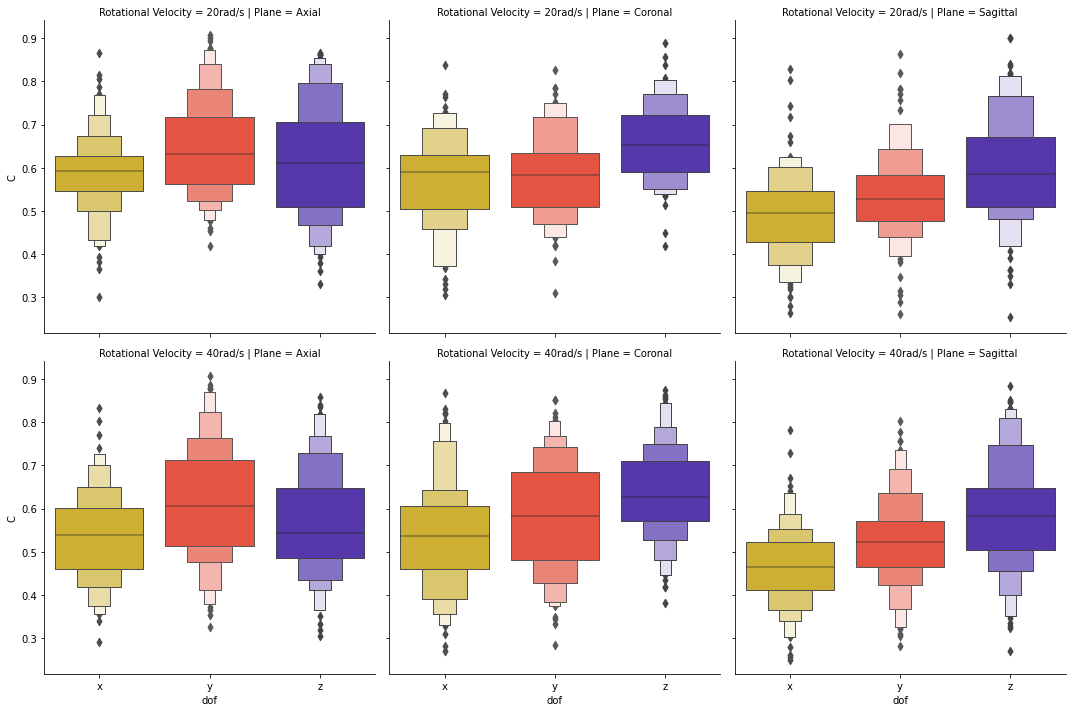

time: 2.61 s (started: 2021-09-01 15:00:41 +01:00)


In [40]:
g = sns.FacetGrid(
    data = cora_scores_all,
    hue = 'dof',
    row = 'Rotational Velocity',
    col = 'Plane',
    palette = colour_palette,
    height = 5,
    aspect = 1
)

g.map(sns.boxenplot, 'dof', 'C', order=['x', 'y', 'z'])

#g.map(sns.swarmplot, 'dof', 'C', order=['x', 'y', 'z'], color = 'k')


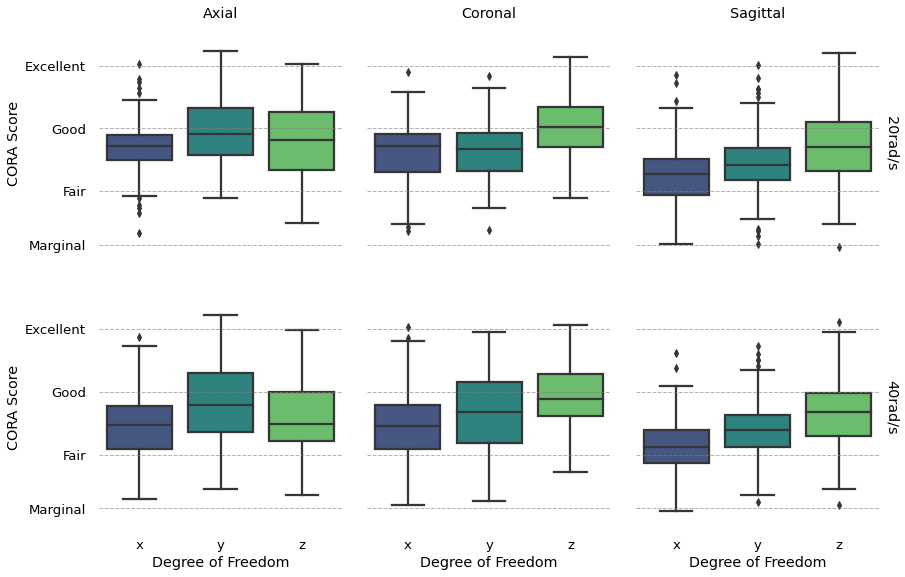

time: 6.67 s (started: 2021-09-01 17:13:35 +01:00)


In [115]:
os.chdir("/rds/general/ephemeral/user/hd1117/ephemeral/verification")
os.chdir("/rds/general/user/hd1117/home/pipeline")
sns.set_context('talk', font_scale=0.8)

i = sns.catplot(
    data = cora_scores_all,
    x = 'dof',
    y = 'C',
    hue = 'dof',
    row = 'Rotational Velocity',
    col = 'Plane',
    kind = 'box',
    palette = 'viridis',
    height = 4,
    aspect = 1,
    dodge=False,
    margin_titles=True
    #cut=0,
    #alpha = 0.7
)

i.set_axis_labels("Degree of Freedom", "CORA Score") \
    .set_titles(row_template = '{row_name}', col_template = '{col_name}') \
    .set(ylim=(0.2, 1)) \
    .despine(left=True, bottom=True)

axes = i.axes.flatten()

for ax in axes:
    ax.set_yticks((0.26, 0.44, 0.65, 0.86))
    ax.set_yticklabels(("Marginal", "Fair", "Good", "Excellent"))
    ax.axhline(0.26, linestyle='--' , linewidth=1, color='grey', alpha = 0.6)
    ax.axhline(0.44, linestyle='--' , linewidth=1, color='grey', alpha = 0.6)
    ax.axhline(0.65, linestyle='--' , linewidth=1, color='grey', alpha = 0.6)
    ax.axhline(0.86, linestyle='--' , linewidth=1, color='grey', alpha = 0.6)
    ax.tick_params(left=False, bottom = False)

#plt.title('CORA scores accross multiple tests')
plt.savefig('CORA scores.png', dpi = 600, bbox_inches='tight', pad_inches=0.1)
plt.savefig('CORA scores.svg', dpi = 600, bbox_inches='tight', pad_inches=0.1)

In [ ]:
# Find first folder number of target displacements
with open(os.path.join(vrf_source_folder, 'b' + vrf_id + '.EV5')) as EV5:

    # Loop through lines until Rx9- X (mm) is found at the end
    for line in EV5: 
        
        print(line)

        if 'Rx9- X' in line.split('|')[-1] and 'INT POSITION' not in line.split('|')[-1]:
            line_num = int(line.split('|')[0])

In [21]:
print(os.path.join(vrf_source_folder, 'b' + vrf_id + '.EV5'))

/rds/general/user/hd1117/home/pipeline/dependencies/verification_data/b12843ascii/b12843.EV5
time: 412 µs (started: 2021-07-12 19:35:45 +01:00)
